# Steel USA — Pipeline V2
**USA — Platts TSI HRC EXW Indiana (STHRI00)**

V2 protocol (validated in experiments M1–M5):
- Temporal **65/15/20** split (train/validation/test); Optuna and Top-3 decided on validation only; test set untouched.
- **One-shot forecasting with ocl = h** (`historical_forecasts`, h ∈ {1, 5, 21, 66}), statistical baselines included.
- Permanent benchmarks: **naive-h** and **drift-h**; headline metric: RelMAE.
- Ensembles with a **temporal gap**; multi-seed with reported dispersion; DM tests (NW and stride = h).
- Error exports compatible with the VaR/FRI layer.


In [1]:
# ============================================
# Config
# ============================================
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import warnings; warnings.filterwarnings("ignore")
import logging; logging.disable(logging.CRITICAL)
import torch
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pipeline_v2p as pv2

CC       = "USA"
TARGET   = "usa_bmk"
DATASET  = "dataset/ds_steel.xlsx"
H_LIST   = [5]
SEEDS    = [42, 43, 44]     # per-model seed dispersion is reported
N_TRIALS = 50               # Optuna on validation (cache: result/v2_hp_usa.xlsx)
FORCE_TUNE = False          # True => ignore cache and re-tune

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})


## 1. Preprocessing, split and data quality


n=5006 | interp_share=0.041 | staleness=0.659
train: ... -> 2019-10-10 (3253 obs)
val:   ... -> 2022-08-26 (751 obs)
test:  ... -> 2026-06-30 (1002 obs)


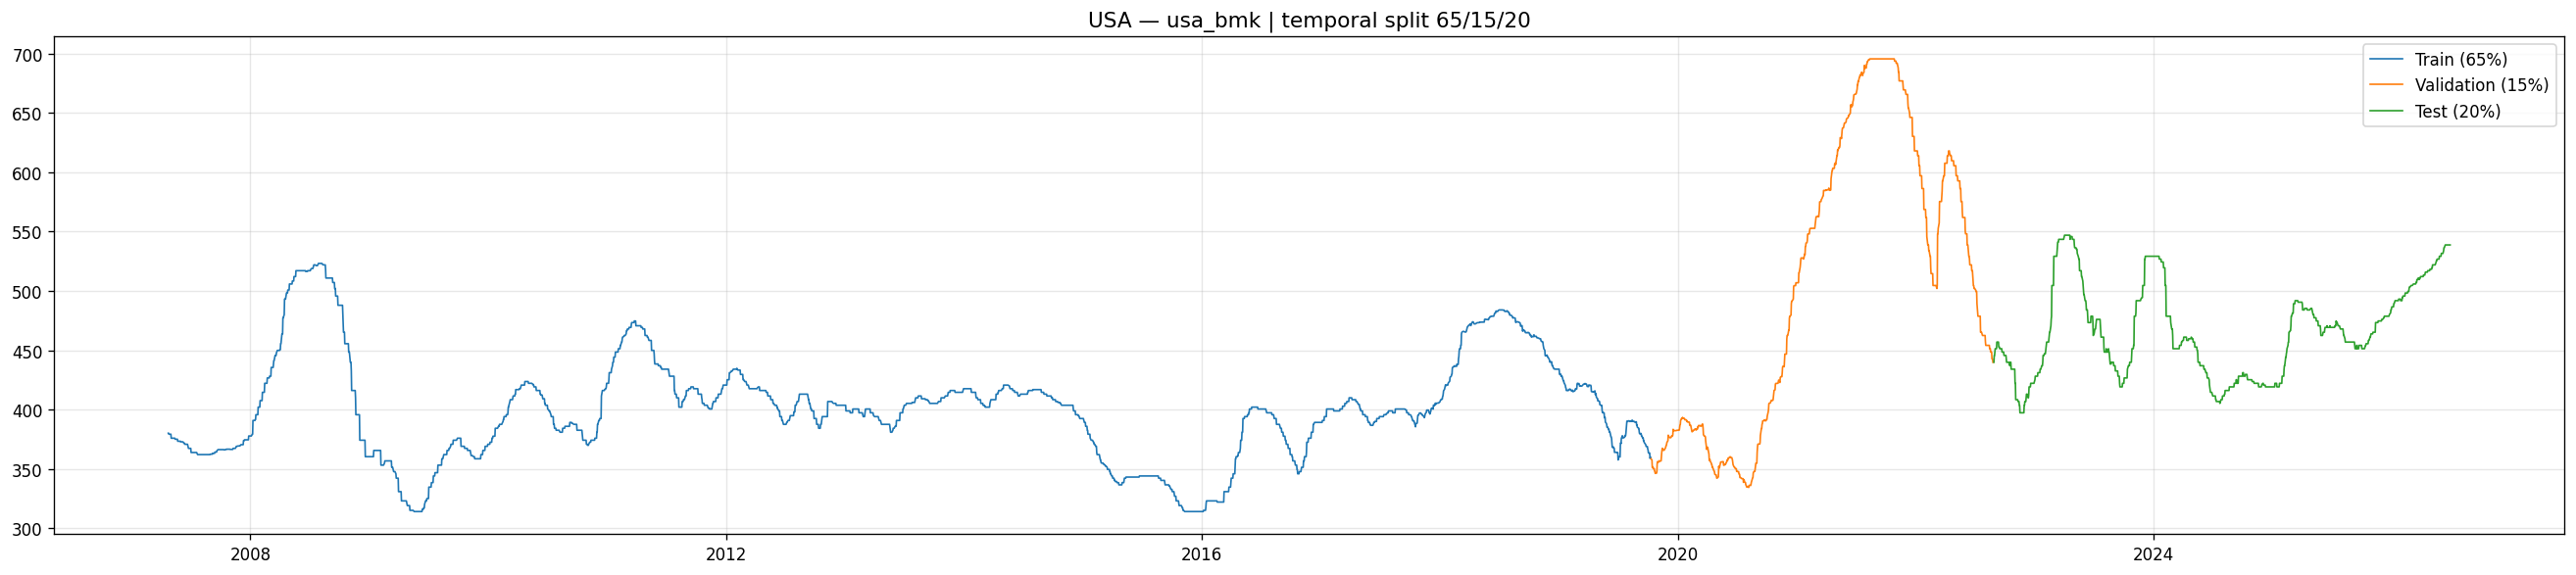

In [2]:
d = pv2.preprocess(TARGET, DATASET)
print(f"n={d['n']} | interp_share={d['interp_share']:.3f} | staleness={d['stale_raw']:.3f}")
print(f"train: ... -> {d['train_o'].end_time().date()} ({d['t1']} obs)")
print(f"val:   ... -> {d['val_o'].end_time().date()} ({d['t2']-d['t1']} obs)")
print(f"test:  ... -> {d['test_o'].end_time().date()} ({d['n']-d['t2']} obs)")
pv2.plot_split_overview(d, CC)


## 2. Full run

`run_country` performs, for each h: Optuna on validation (cached), refit on
train+validation with multiple seeds, `historical_forecasts` on the test set,
statistical baselines under the same protocol, naive/drift benchmarks,
ensembles with the validation Top-3, metrics + DM tests, and exports
`result/v2_result_steel_*.xlsx`.

⚠️ First run (no hp cache): several hours. Re-runs use the cache.


In [3]:
res = pv2.run_country(CC, TARGET, DATASET, h_list=H_LIST, seeds=SEEDS,
                      n_trials=N_TRIALS, force_tune=FORCE_TUNE)
summary = res["summary"]


USA: preprocessing (65/15/20 split)...
  n=5006 | train until 2019-10-10 | val until 2022-08-26 | test until 2026-06-30
  interp_share=0.041 | staleness=0.659

----- USA | h=5 -----
  [RNN|h=5] Optuna (50 trials on validation, pinball)...
  [RNN|h=5] val_pinball=8.85624 (2380.9s)
  [RNN|h=5] test pinball=3.69920 | SMAPE(med)=1.8178 (±0.14897 pb across 3 seeds)
  [Transformer|h=5] Optuna (50 trials on validation, pinball)...
  [Transformer|h=5] val_pinball=13.34790 (6269.8s)
  [Transformer|h=5] test pinball=5.50327 | SMAPE(med)=4.4065 (±0.59533 pb across 3 seeds)
  [N-HiTS|h=5] Optuna (50 trials on validation, pinball)...
  [N-HiTS|h=5] val_pinball=2.10612 (1894.6s)
  [N-HiTS|h=5] test pinball=1.39785 | SMAPE(med)=1.0782 (±0.06419 pb across 3 seeds)
  [DLinear|h=5] Optuna (50 trials on validation, pinball)...
  [DLinear|h=5] val_pinball=1.42831 (1051.4s)
  [DLinear|h=5] test pinball=1.27366 | SMAPE(med)=0.9407 (±0.05698 pb across 3 seeds)
  [TCN|h=5] Optuna (50 trials on validation, pin

d:\dl_darts\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  [ARIMA] ok (28.8s)
  [ExpSmoothing] FAILED: LocalForecastingModel does not support historical forecasting with `retrain` set to `False`. For now, this is only supported with GlobalForecastingModels such as TorchForecastingModels. For more information, read the documentation for `retrain` in `historical_forecasts()`
  [LinearRegression] ok (0.3s)
  Top-3 (validation, pinball): ['DLinear', 'TCN', 'N-HiTS']
  ✔ h=5 checkpointed (result/v2p_ckpt_usa.xlsx)

✅ result/v2p_result_steel_usa.xlsx saved


## 3. Result tables


In [4]:
for h in H_LIST:
    blk = summary[summary.h == h].sort_values("RelMAE_vs_NaiveH")
    print(f"\n===== {CC} | h={h} =====")
    print(blk[["Model", "SMAPE", "RMSE", "MASE", "Cover90", "PB05", "PB95",
               "Winkler90", "RelMAE_vs_NaiveH", "DMstride_p_one", "Seed_std_PB"]]
          .round(4).to_string(index=False))


===== USA | h=5 =====
           Model  SMAPE    RMSE   MASE  Cover90   PB05   PB95  Winkler90  RelMAE_vs_NaiveH  DMstride_p_one  Seed_std_PB
           ARIMA 0.9276  6.5316 1.5246      NaN    NaN    NaN        NaN            0.9465          0.0158          NaN
             TCN 0.9335  6.6200 1.5359   0.8156 0.7314 0.7739    30.1055            0.9535          0.0080       0.0368
LinearRegression 0.9336  6.6100 1.5385      NaN    NaN    NaN        NaN            0.9551          0.0317          NaN
         DLinear 0.9407  6.6778 1.5454   0.8788 0.7660 0.8666    32.6529            0.9594          0.0127       0.0570
     EnsDynSMAPE 0.9451  6.7519 1.5502   0.8928 0.7281 0.7594    29.7484            0.9624          0.0263          NaN
         EnsMean 0.9498  6.7692 1.5579   0.8928 0.7311 0.7607    29.8370            0.9672          0.0313          NaN
   EnsPinballDyn 0.9516  6.7708 1.5611   0.8918 0.7316 0.7584    29.7990            0.9692          0.0326          NaN
       EnsShrink 

## 4. Plots


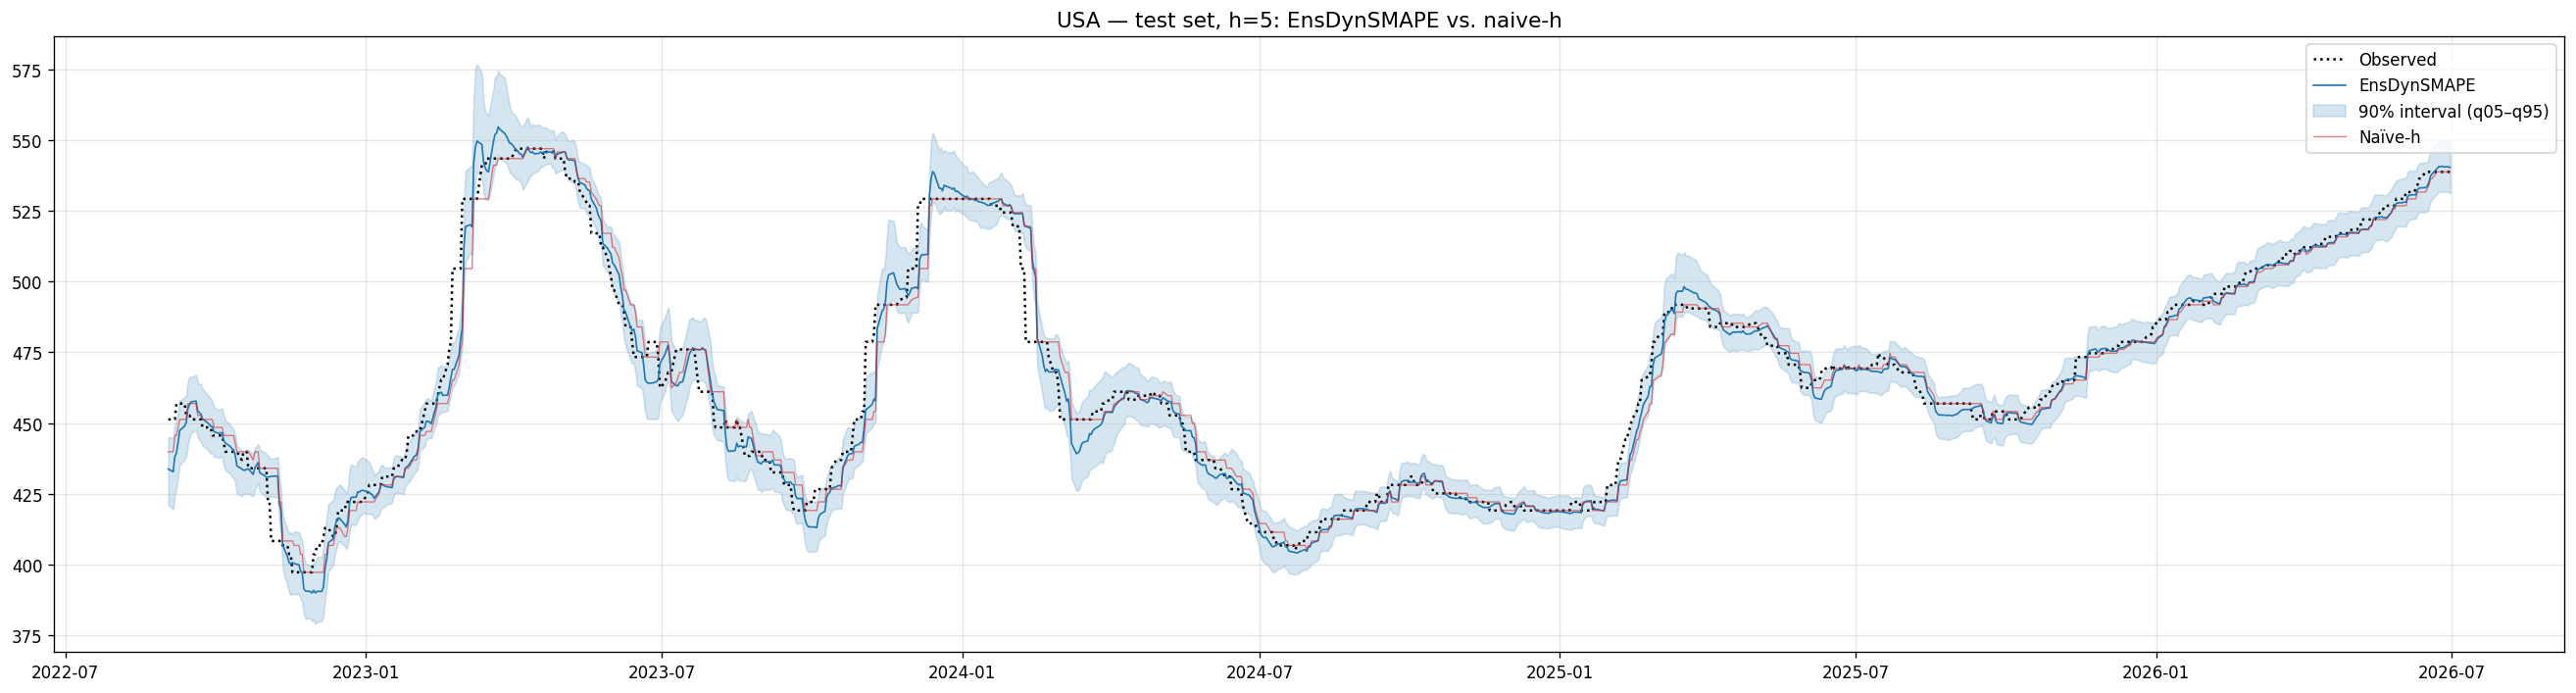

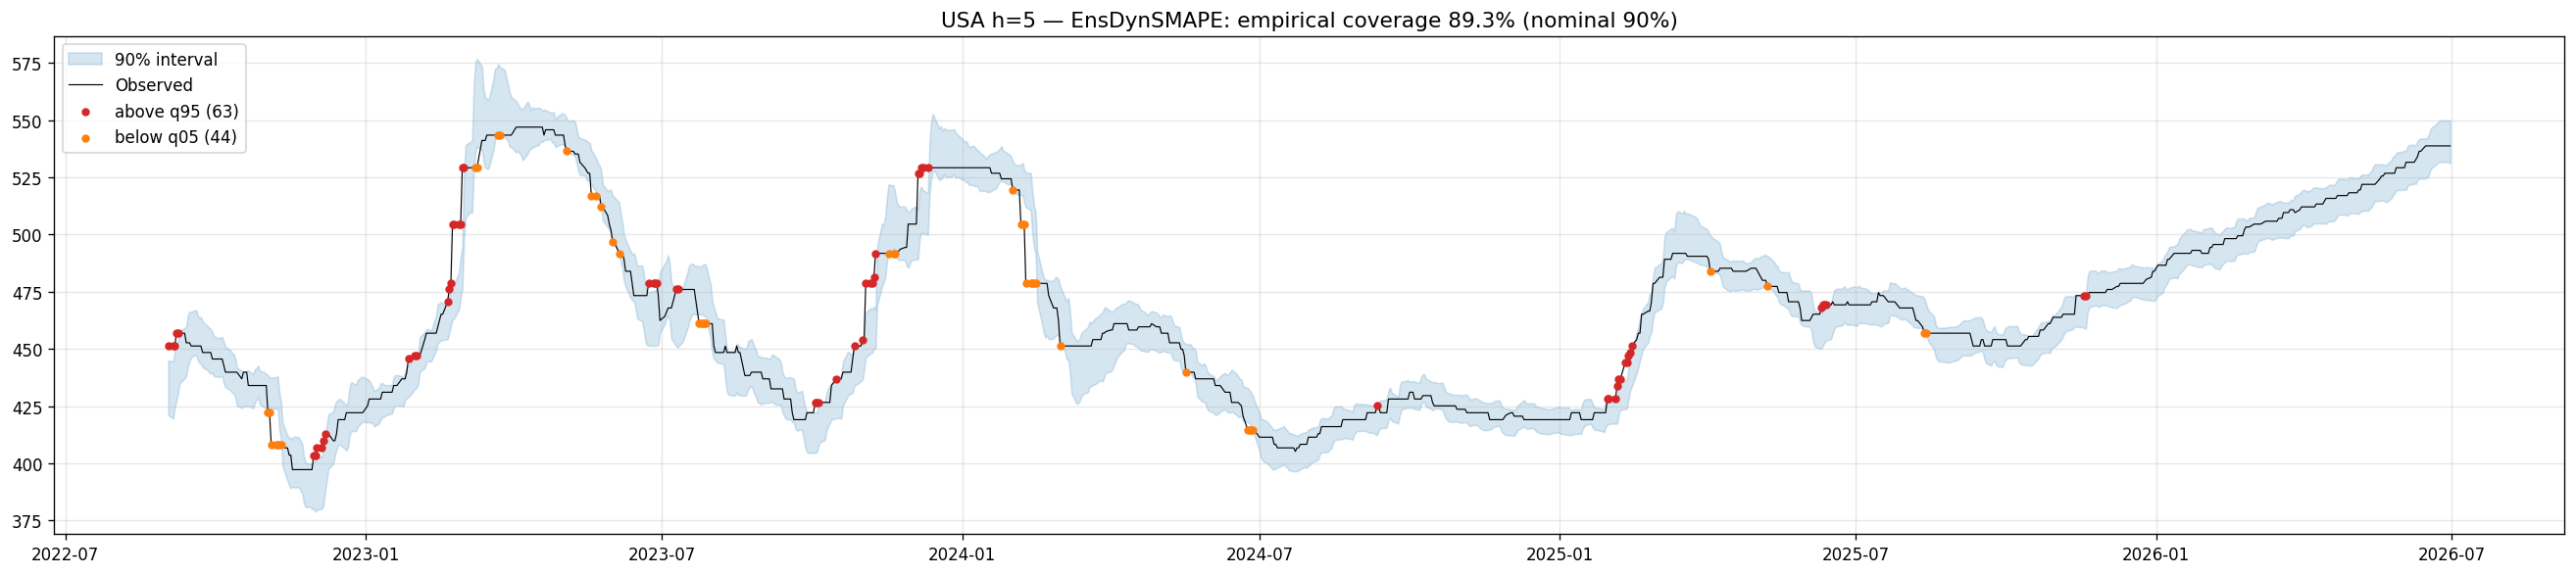

Best (rank_prob) at h=5: EnsDynSMAPE


In [5]:
# Best candidate (RelMAE) vs naive-h at the longest horizon
h_show = H_LIST[0]   # h=5

rankp = res.get("rank_prob")
if rankp is not None and len(rankp):
    best = rankp[rankp.h == h_show].sort_values("TOTAL_scr", ascending=False).iloc[0]["Model"]
else:
    blk = summary[(summary.h == h_show) & (~summary.Model.isin(["NaiveH", "DriftH"]))]
    best = blk.sort_values("PB95").iloc[0]["Model"]

pfx = pv2.MODEL_PREFIX.get(best, best)
pv2.plot_test_forecast(res["err_sheets"][h_show], pfx, CC, h_show)      # banda q05–q95
pv2.plot_interval_coverage(res["err_sheets"][h_show], pfx, CC, h_show)  # excedências vs. cobertura
print(f"Best (rank_prob) at h={h_show}: {best}")



## 5. Next phase

The `error_<cc>_h<h>` sheets in `result/v2_result_steel_*.xlsx` feed the
VaR/FRI layer (Kupiec/Christoffersen/DQ backtesting + dynamic Basel
Traffic-Light) in the same format as the original error sheets. The pooled
cross-market test (Fisher) runs in the consolidation notebook once all four
countries are done.

Oil ablation (M6, after updating dataset/ds_oil.xlsx through Jun/2026):
`pv2.run_country(CC, TARGET, DATASET, h_list=H_LIST, seeds=SEEDS,
n_trials=N_TRIALS, oil_path="dataset/ds_oil.xlsx", tag="oil")` — reuses the
hp cache, writes to `v2_result_steel_*_oil.xlsx`.
